# Assignment TACD 2025/2026


1. Business Understanding
2. Data Understanding
3. Data Transformation
4. Modelling

In [94]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split


DATA_DIR = Path("ml-latest-small")
ratings_path = DATA_DIR / "ratings.csv"
movies_path = DATA_DIR / "movies.csv"

## 1. Business Understanding

The business problem is to help a movie platform recommend relevant films to each user based on past interactions. From a business perspective, higher recommendation quality directly translates to increased user engagement, longer session times, and higher retention rates — all of which drive subscription revenue and reduce churn.

Success can be evaluated by the quality of top-N recommendations on unseen data. The primary metrics used are Precision@k and Recall@k, which can be computed for different values of k (e.g. k = 3, 5, 10) to reflect varying recommendation list lengths, alongside their harmonic mean F1@k and the mean of those metrics across users (Mean Precision@k, Mean Recall@k, Mean F1@k). Precision and Recall are well-suited to this task because they directly reflect the two core objectives of a recommender system: ensuring that every suggested item is relevant to the user, and ensuring that relevant items in the catalog are not missed. NDCG (Normalized Discounted Cumulative Gain) could also be computed as it additionally rewards correct ranking order within the list; however, since the evaluation focuses on whether relevant items appear in the top-k set rather than their precise ordering within it, NDCG was omitted for brevity.

From a practical point of view, the solution should also work well with sparse data and remain usable when users have rated only a small number of movies. A non-personalised popularity baseline — recommending the most-rated movies to every user — will serve as a lower bound to confirm that learned models add value over a trivial solution.

This can be translated into two machine learning problems. The first is an explicit-feedback task, where we predict the rating a user may give to a movie. The second is a ranking task, where we predict which unseen movies should appear at the top of the recommendation list.
From an operational perspective, the main limitations are cold-start users (new users with no history cannot receive personalised recommendations) and the static nature of the dataset (in production, the catalog and user preferences change over time, so models would need periodic retraining).

## 2. Data Understanding

In [95]:
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

ratings["timestamp_dt"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
ratings.head()

ratings shape: (100836, 5)
movies shape: (9742, 3)


,userId,movieId,rating,timestamp,timestamp_dt
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


In [96]:
n_ratings = len(ratings)
n_users = ratings["userId"].nunique()
n_rated_movies = ratings["movieId"].nunique()
catalog_movies = movies["movieId"].nunique()
density = n_ratings / (n_users * n_rated_movies)

print("Number of ratings:", n_ratings)
print("Number of users:", n_users)
print("Number of rated movies:", n_rated_movies)
print("Number of movies in catalog:", catalog_movies)
print("Rating scale:", ratings["rating"].min(), "to", ratings["rating"].max())
print("Average rating:", round(ratings["rating"].mean(), 3))
print("Median rating:", ratings["rating"].median())
print("First interaction:", ratings["timestamp_dt"].min())
print("Last interaction:", ratings["timestamp_dt"].max())
print(f"User-item matrix density: {density:.4%}")

Number of ratings: 100836
Number of users: 610
Number of rated movies: 9724
Number of movies in catalog: 9742
Rating scale: 0.5 to 5.0
Average rating: 3.502
Median rating: 3.5
First interaction: 1996-03-29 18:36:55
Last interaction: 2018-09-24 14:27:30
User-item matrix density: 1.7000%


The dataset contains 610 users and 9724 rated movies. The density is low, so the user-item matrix is sparse.

In [97]:
print("Missing values by column:")
print(ratings.isna().sum())
print("Column types:")
print(ratings.dtypes)
print("Duplicated (userId, movieId) pairs:", ratings.duplicated(subset=["userId", "movieId"]).sum())

Missing values by column:
userId          0
movieId         0
rating          0
timestamp       0
timestamp_dt    0
dtype: int64
Column types:
userId                  int64
movieId                 int64
rating                float64
timestamp               int64
timestamp_dt    datetime64[s]
dtype: object
Duplicated (userId, movieId) pairs: 0


There are no missing values in the `ratings` table and there are no duplicated `(userId, movieId)` pairs.

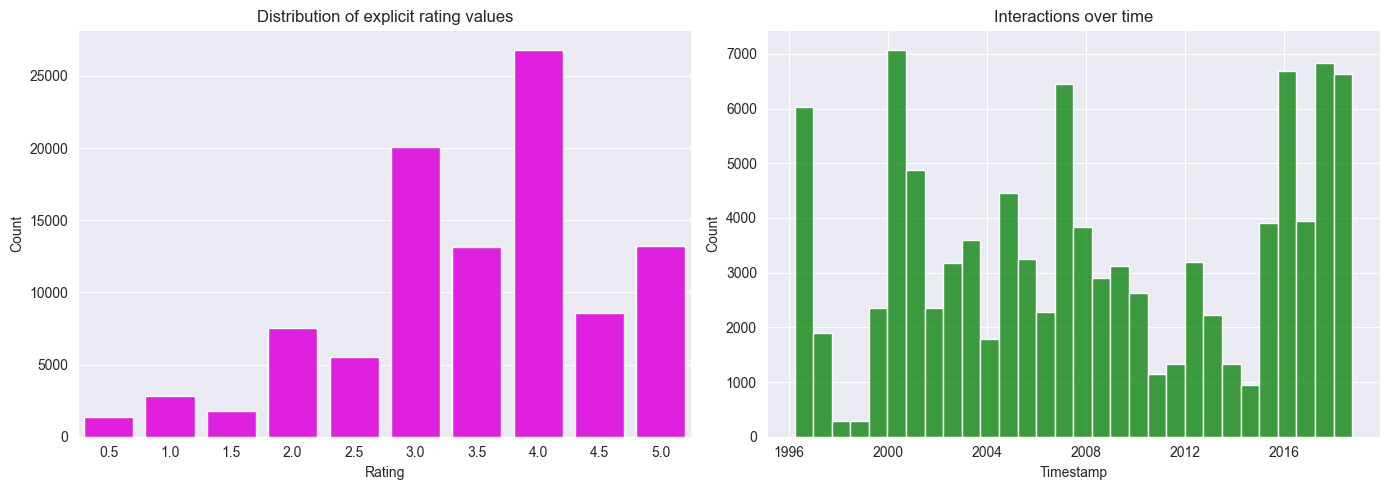

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=ratings, x="rating", ax=axes[0], color="magenta")
axes[0].set_title("Distribution of explicit rating values")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

sns.histplot(ratings["timestamp_dt"], bins=30, ax=axes[1], color="green")
axes[1].set_title("Interactions over time")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The rating distribution is concentrated around higher scores, especially 4.0. This indicates that users are more prone to rate movies they like. Interactions over time are irregular, with clear peaks and drops, which shows that activity is not constant across the years.

In [99]:
user_activity = ratings.groupby("userId").size().rename("basket_size")
item_popularity = ratings.groupby("movieId").size().rename("rating_count")

print("Basket size summary:")
print(user_activity.describe())
print("\nMovie popularity summary:")
print(item_popularity.describe())
print("\nTop 10 most active users:")
print(user_activity.sort_values(ascending=False).head(10))
print("\nTop 10 most rated movies:")
top_movies = (item_popularity.sort_values(ascending=False).head(10).reset_index().merge(movies[["movieId", "title"]], on="movieId", how="left"))
print(top_movies[["movieId", "title", "rating_count"]].to_string(index=False))

Basket size summary:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: basket_size, dtype: float64

Movie popularity summary:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating_count, dtype: float64

Top 10 most active users:
userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: basket_size, dtype: int64

Top 10 most rated movies:
 movieId                                     title  rating_count
     356                       Forrest Gump (1994)           329
     318          Shawshank Redemption, The (1994)           317
     296                       Pulp Fiction (1994)           307
     593          Silence of the Lambs, The (1991)           279
    2571 

User activity and movie popularity are uneven. A small number of users and movies generate a large part of the interactions, which is typical for recommender-system data.

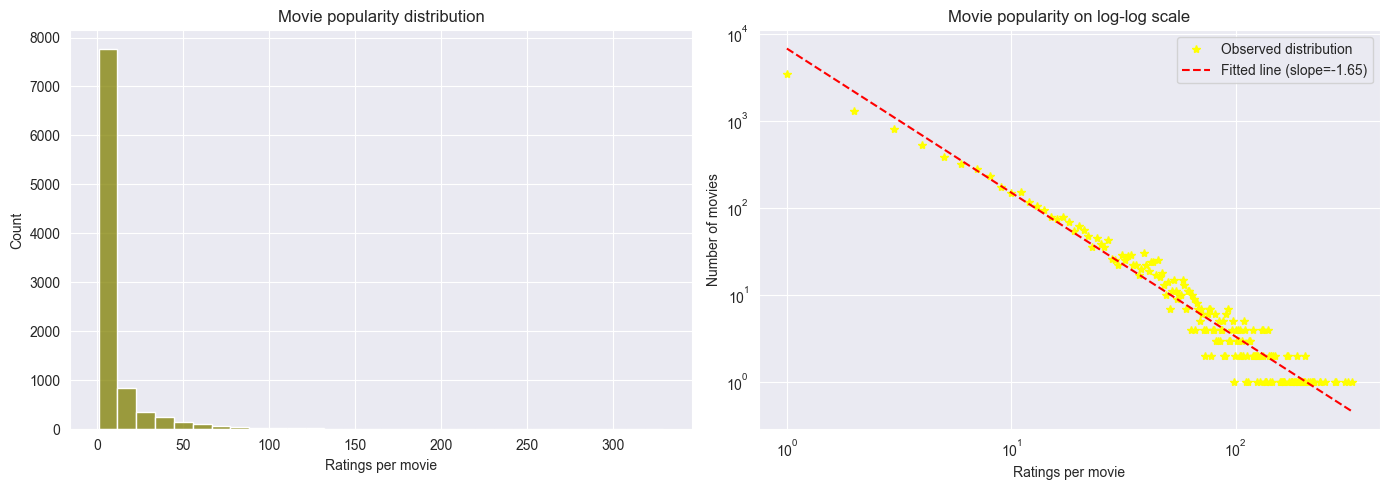

Estimated log-log slope (item popularity): -1.65


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(item_popularity, bins=30, ax=axes[0], color="olive")
axes[0].set_title("Movie popularity distribution")
axes[0].set_xlabel("Ratings per movie")

movie_popularity_counts = item_popularity.value_counts().sort_index()
mx = movie_popularity_counts.index.astype(float)
my = movie_popularity_counts.values.astype(float)
m_slope, m_intercept = np.polyfit(np.log10(mx), np.log10(my), 1)
m_fitted_y = 10 ** m_intercept * (mx ** m_slope)

axes[1].loglog(mx, my, marker="*", linestyle="none",color="yellow", label="Observed distribution")
axes[1].loglog(mx, m_fitted_y, linestyle="--", color="red",
               label=f"Fitted line (slope={m_slope:.2f})")
axes[1].set_title("Movie popularity on log-log scale")
axes[1].set_xlabel("Ratings per movie")
axes[1].set_ylabel("Number of movies")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Estimated log-log slope (item popularity):", round(m_slope, 2))

Movie popularity is long-tailed. The log-log plot is approximately linear with a negative slope, consistent with a heavy-tail pattern. As with basket size, we treat this as power-law-like rather than claiming a strict power law without a formal test.

In [101]:
unrated_movies = movies[~movies["movieId"].isin(ratings["movieId"])].shape[0]
genre_counts = movies["genres"].str.split("|").explode().value_counts().head(10)

print("Movies in catalog but never rated:", unrated_movies)
print("\nTop 10 genres in the movies table:")
print(genre_counts.to_string())

Movies in catalog but never rated: 18

Top 10 genres in the movies table:
genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779


The `movies` table adds useful context: the catalog is slightly larger than the rated subset, so a few movies have no ratings at all. The catalog is broad, with Drama and Comedy being the most common genres. Genre information is not used in the current collaborative filtering models, but could serve as content features in a later content-based extension.

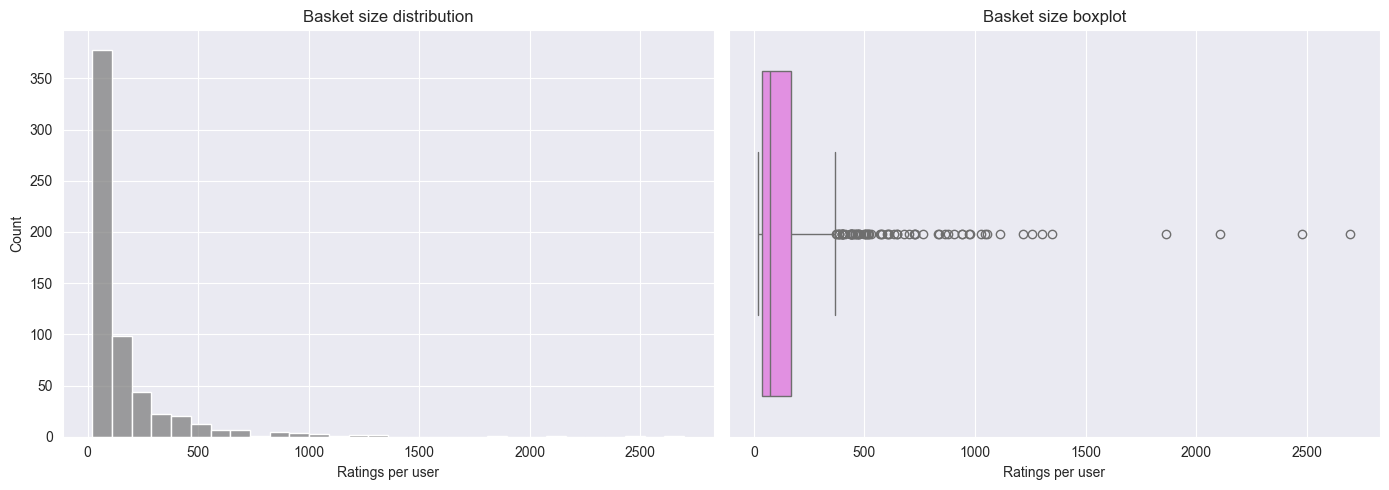

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(user_activity, bins=30, ax=axes[0], color="grey")
axes[0].set_title("Basket size distribution")
axes[0].set_xlabel("Ratings per user")

sns.boxplot(x=user_activity, ax=axes[1], color="violet")
axes[1].set_title("Basket size boxplot")
axes[1].set_xlabel("Ratings per user")

plt.tight_layout()
plt.show()

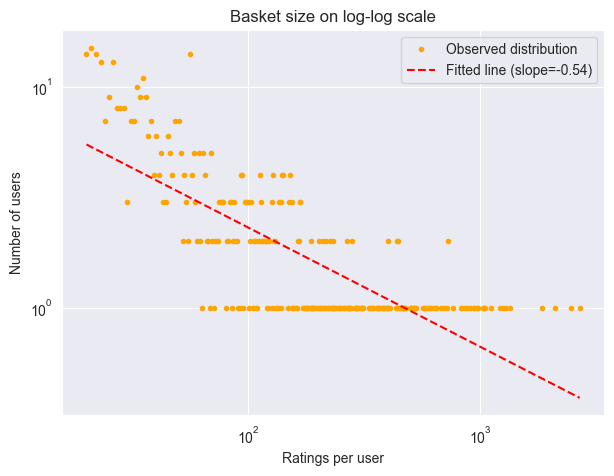

Estimated log-log slope: -0.54


In [103]:
basket_counts = user_activity.value_counts().sort_index()
x = basket_counts.index.astype(float)
y = basket_counts.values.astype(float)

slope, intercept = np.polyfit(np.log10(x), np.log10(y), 1)
fitted_y = 10 ** intercept * (x ** slope)

plt.figure(figsize=(7, 5))
plt.loglog(x, y, marker=".", linestyle="none",color="orange", label="Observed distribution")
plt.loglog(x, fitted_y, linestyle="--", color="red", label=f"Fitted line (slope={slope:.2f})")
plt.title("Basket size on log-log scale")
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.legend()
plt.show()

print("Estimated log-log slope:", round(slope, 2))

Basket size shows a right-skewed distribution with a long tail, but the log-log plot does not align closely with the fitted line, suggesting the distribution is not well described by a power law. A small number of highly active users rate substantially more movies than the majority.

### Main findings from data understanding
- The ratings matrix is very sparse.
- User activity is uneven with a small number of highly active users versus many rather inactive users.
- Movie popularity is also uneven and concentrated on a small number of films with a high number of ratings.
- Basket size has a heavy tail, but is not well described by a power law.

## 3. Data Transformation

Before modelling, we need to prepare the data in a simpler format. The main steps are keeping the relevant columns, converting user and movie ids into numeric indices, creating an explicit version with ratings, creating a binary version for positive interactions, and splitting the data into train, validation and test sets.
We convert original user and movie ids into consecutive numeric indices to make it is easier to build user-item matrices for the recommendation models. The explicit version is needed for rating-prediction methods such as collaborative filtering or matrix-factorization approaches, while the implicit binary version is more appropriate for ranking methods, such as BPR or NCF. We define an implicit positive interaction as a rating of 4.0 or higher. Converting lower ratings (e.g., 1 or 2 stars) into positive implicit signals would incorrectly train the ranking models to recommend movies the user disliked.

In [104]:
ratings_model = ratings[["userId", "movieId", "rating", "timestamp", "timestamp_dt"]].copy()
user_ids = np.sort(ratings_model["userId"].unique())
movie_ids = np.sort(ratings_model["movieId"].unique())
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}
ratings_model["user_idx"] = ratings_model["userId"].map(user_to_idx)
ratings_model["movie_idx"] = ratings_model["movieId"].map(movie_to_idx)
print(ratings_model.head(10))

IMPLICIT_THRESHOLD = 4.0
# Create the base implicit dataset (Positive interactions only)
implicit_feedback = ratings_model.assign( interaction=(ratings_model["rating"] >= IMPLICIT_THRESHOLD).astype(np.int8))
implicit_feedback = implicit_feedback[implicit_feedback["interaction"] == 1].copy()

   userId  movieId  rating  timestamp        timestamp_dt  user_idx  movie_idx
0       1        1     4.0  964982703 2000-07-30 18:45:03         0          0
1       1        3     4.0  964981247 2000-07-30 18:20:47         0          2
2       1        6     4.0  964982224 2000-07-30 18:37:04         0          5
3       1       47     5.0  964983815 2000-07-30 19:03:35         0         43
4       1       50     5.0  964982931 2000-07-30 18:48:51         0         46
5       1       70     3.0  964982400 2000-07-30 18:40:00         0         62
6       1      101     5.0  964980868 2000-07-30 18:14:28         0         89
7       1      110     4.0  964982176 2000-07-30 18:36:16         0         97
8       1      151     5.0  964984041 2000-07-30 19:07:21         0        124
9       1      157     5.0  964984100 2000-07-30 19:08:20         0        130


To ensure our models have enough signal to learn and to allow for proper chronological data splitting, we exclude users with fewer than 5 positive interactions.

In [105]:
MIN_INTERACTIONS = 5
eligible_users = implicit_feedback.groupby("userId").size().loc[lambda s: s >= MIN_INTERACTIONS].index

implicit_filtered = implicit_feedback[implicit_feedback["userId"].isin(eligible_users)].copy()
explicit_filtered = ratings_model[ratings_model["userId"].isin(eligible_users)].copy()

print("Users before filtering:", ratings_model["userId"].nunique())
print("Users after filtering:", explicit_filtered["userId"].nunique())

Users before filtering: 610
Users after filtering: 603


We draw a 20% random sample of eligible users as a probe set. Models will be developed and debugged on this smaller subset before scaling to the full data. This saves computing time as well as power and enables us to detect implementation errors early.

In [106]:
RANDOM_STATE = 42
unique_eligible_users = implicit_filtered["userId"].unique()
sampled_users, _ = train_test_split(unique_eligible_users, train_size=0.2, random_state=RANDOM_STATE)

probe_implicit = implicit_filtered[implicit_filtered["userId"].isin(sampled_users)].copy()
probe_explicit = explicit_filtered[explicit_filtered["userId"].isin(sampled_users)].copy()

In [107]:
print("Eligible users basket size summary:")
print(explicit_filtered.groupby("userId").size().describe())
print("\nProbe sample basket size summary:")
print(probe_explicit.groupby("userId").size().describe())

Eligible users basket size summary:
count     603.000000
mean      166.943615
std       270.609648
min        20.000000
25%        36.000000
50%        73.000000
75%       170.500000
max      2698.000000
dtype: float64

Probe sample basket size summary:
count     120.000000
mean      155.275000
std       202.012603
min        20.000000
25%        32.750000
50%        64.500000
75%       192.250000
max      1346.000000
dtype: float64


This probe sample is a smaller subset of users that should be used first to make the models run, debug the pipeline, and compare initial results before training on the full dataset. It also has its own train, validation and test split, so the same evaluation logic can be tested on the smaller sample before moving to the full data. The basket-size distribution of the probe sample is similar to the full eligible dataset, so the sample is representative enough for initial experiments.

A chronological split is applied to preserve temporal integrity, ensuring that no future interactions leak into the training set. The split is 70% train, 15% validation and 15% test, which gives enough data for training while still leaving separate data for tuning and evaluation.

In [108]:
def chronological_user_split(df, user_col="userId", time_col="timestamp", train_size=0.7, val_size=0.15):
    train_parts, val_parts, test_parts = [], [], []

    for _, user_df in df.sort_values([user_col, time_col]).groupby(user_col):
        n = len(user_df)
        train_end = max(1, int(np.floor(n * train_size)))
        val_end = max(train_end + 1, int(np.floor(n * (train_size + val_size)))) if n >= 3 else train_end

        if n == 1:
            train_parts.append(user_df)
            continue
        if n == 2:
            train_parts.append(user_df.iloc[:1])
            test_parts.append(user_df.iloc[1:])
            continue
        if n == 3:
            train_parts.append(user_df.iloc[:1])
            val_parts.append(user_df.iloc[1:2])
            test_parts.append(user_df.iloc[2:])
            continue

        train_parts.append(user_df.iloc[:train_end])
        val_parts.append(user_df.iloc[train_end:val_end])
        test_parts.append(user_df.iloc[val_end:])

    train_df = pd.concat(train_parts).reset_index(drop=True) if train_parts else pd.DataFrame(columns=df.columns)
    val_df = pd.concat(val_parts).reset_index(drop=True) if val_parts else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_parts).reset_index(drop=True) if test_parts else pd.DataFrame(columns=df.columns)
    return train_df, val_df, test_df
# Split the FULL datasets
explicit_train, explicit_val, explicit_test = chronological_user_split(explicit_filtered)
implicit_train, implicit_val, implicit_test = chronological_user_split(implicit_filtered)

# Split the PROBE datasets
probe_explicit_train, probe_explicit_val, probe_explicit_test = chronological_user_split(probe_explicit)
probe_implicit_train, probe_implicit_val, probe_implicit_test = chronological_user_split(probe_implicit)

print(f"Full  — explicit train: {len(explicit_train)}, val: {len(explicit_val)}, test: {len(explicit_test)}")
print(f"Full  — implicit train: {len(implicit_train)}, val: {len(implicit_val)}, test: {len(implicit_test)}")
print(f"Probe — explicit train: {len(probe_explicit_train)}, val: {len(probe_explicit_val)}, test: {len(probe_explicit_test)}")
print(f"Probe — implicit train: {len(probe_implicit_train)}, val: {len(probe_implicit_val)}, test: {len(probe_implicit_test)}")

Full  — explicit train: 70197, val: 15077, test: 15393
Full  — implicit train: 33719, val: 7260, test: 7583
Probe — explicit train: 12992, val: 2787, test: 2854
Probe — implicit train: 6032, val: 1300, test: 1369


### Transformation conclusions
- We prepared a simpler table for modelling.
- We created explicit and implicit versions of the data for different recommendation settings.
- We split the data into train, validation and test parts.

## Summary of what was done - this is just for you to know, we will delete it in the end

In section 1, I defined the business problem: recommending relevant movies to users based on past interactions. I also wrote the success criteria and translated the problem into two machine learning settings: explicit rating prediction and top-N ranking. This is needed so that the later modelling choices are clearly connected to the goal of the recommender system. If you have any other ideas or approaches in mind, you can add them.

In section 2, I analysed the `ratings` table. I checked the number of users, movies and ratings, looked at the rating distribution, examined interactions over time, and analysed basket size and user activity. I also checked data quality by looking for missing values and duplicated `(userId, movieId)` pairs. This is needed to understand the structure of the dataset before building models and to justify later modelling decisions.

In section 3, I prepared the data for recommendation models. I created `ratings_model`, converted original ids into numeric indices,created the `implicit_feedback` table and `implicit_matrix`, filtered users with too few positive interactions, and split the data into train, validation and test sets in chronological order. This is needed because the next parts of the project require data in a form that can be used directly by recommendation algorithms.

I also prepared a probe sample, which is a 20% subset of users for quick experiments. It should be used first to test whether the models run correctly, whether the evaluation code works, and whether the first results are reasonable before moving to the full dataset.

So for the next parts, the main job is training the models, tuning them, and comparing them with metrics. Fo first use
`probe_explicit_train`, `probe_explicit_val`, `probe_explicit_test` or
`probe_implicit_train`, `probe_implicit_val`, `probe_implicit_test`

## 4. Modeling (Probe Sample)

Before training our baseline models, we must convert our training dataframes into the specific mathematical structures required by the algorithms:
1. **Association Rules (AR):** Requires a transactional "list of lists" format.
2. **Collaborative Filtering (CF) & Matrix Factorization (MFPQ):** Require Sparse Matrices.

Association Rules Baskets

In [109]:
ar_baskets_train = implicit_train.groupby('user_idx')['movie_idx'].apply(list).tolist()
ar_baskets_probe_train = probe_implicit_train.groupby('user_idx')['movie_idx'].apply(list).tolist()

if len(ar_baskets_probe_train) > 0:
    print(f"Sample AR basket (first user's items): {ar_baskets_probe_train[0][:10]}")

Sample AR basket (first user's items): [7355, 8810, 8448, 2670, 7241, 4607, 8287, 6784, 6236, 291]


sparse matrices for MAtrix Factorization and Collaborative Filtering

In [110]:
matrix_shape = (len(user_ids), len(movie_ids))

# PROBE MATRICES
# Explicit
probe_explicit_train_matrix = sparse.csr_matrix((probe_explicit_train["rating"].astype(np.float32), (probe_explicit_train["user_idx"], probe_explicit_train["movie_idx"])), shape=matrix_shape)
probe_explicit_val_matrix = sparse.csr_matrix((probe_explicit_val["rating"].astype(np.float32), (probe_explicit_val["user_idx"], probe_explicit_val["movie_idx"])), shape=matrix_shape)
probe_explicit_test_matrix = sparse.csr_matrix((probe_explicit_test["rating"].astype(np.float32), (probe_explicit_test["user_idx"], probe_explicit_test["movie_idx"])), shape=matrix_shape)

# Implicit
probe_implicit_train_matrix = sparse.csr_matrix((probe_implicit_train["interaction"].astype(np.float32), (probe_implicit_train["user_idx"], probe_implicit_train["movie_idx"])), shape=matrix_shape)
probe_implicit_val_matrix = sparse.csr_matrix((probe_implicit_val["interaction"].astype(np.float32), (probe_implicit_val["user_idx"], probe_implicit_val["movie_idx"])), shape=matrix_shape)
probe_implicit_test_matrix = sparse.csr_matrix((probe_implicit_test["interaction"].astype(np.float32), (probe_implicit_test["user_idx"], probe_implicit_test["movie_idx"])), shape=matrix_shape)


#FULL MATRICES
# Explicit
explicit_train_matrix = sparse.csr_matrix((explicit_train["rating"].astype(np.float32), (explicit_train["user_idx"], explicit_train["movie_idx"])), shape=matrix_shape)
explicit_val_matrix = sparse.csr_matrix((explicit_val["rating"].astype(np.float32), (explicit_val["user_idx"], explicit_val["movie_idx"])), shape=matrix_shape)
explicit_test_matrix = sparse.csr_matrix((explicit_test["rating"].astype(np.float32), (explicit_test["user_idx"], explicit_test["movie_idx"])), shape=matrix_shape)

# Implicit
implicit_train_matrix = sparse.csr_matrix((implicit_train["interaction"].astype(np.float32), (implicit_train["user_idx"], implicit_train["movie_idx"])), shape=matrix_shape)
implicit_val_matrix = sparse.csr_matrix((implicit_val["interaction"].astype(np.float32), (implicit_val["user_idx"], implicit_val["movie_idx"])), shape=matrix_shape)
implicit_test_matrix = sparse.csr_matrix((implicit_test["interaction"].astype(np.float32), (implicit_test["user_idx"], implicit_test["movie_idx"])), shape=matrix_shape)

print(f"Probe Implicit Train Matrix nnz: {probe_implicit_train_matrix.nnz}")
print(f"Probe Implicit Val Matrix nnz: {probe_implicit_val_matrix.nnz}")
print(f"Probe Implicit Test Matrix nnz: {probe_implicit_test_matrix.nnz}")

Probe Implicit Train Matrix nnz: 6032
Probe Implicit Val Matrix nnz: 1300
Probe Implicit Test Matrix nnz: 1369
